In [1]:
import pandas as pd
import numpy as np



In [2]:
from google.colab import files
files.upload()


Saving EE red survey (Responses).xlsx to EE red survey (Responses).xlsx
Saving EE survey blue responses.xlsx to EE survey blue responses.xlsx


{'EE red survey (Responses).xlsx': b'PK\x03\x04\x14\x00\x06\x00\x08\x00\x00\x00!\x00d-t\rx\x01\x00\x00\x90\x05\x00\x00\x13\x00\x08\x02[Content_Types].xml \xa2\x04\x02(\xa0\x00\x02\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\

In [3]:
import os
os.listdir(".")


['.config',
 'EE red survey (Responses).xlsx',
 'EE survey blue responses.xlsx',
 'sample_data']

In [4]:
import pandas as pd

blue = pd.read_excel("EE survey blue responses.xlsx")
red  = pd.read_excel("EE red survey (Responses).xlsx")

blue["dataset"] = "Blue"
red["dataset"] = "Red"

df = pd.concat([blue, red], ignore_index=True)

print("Loaded shape:", df.shape)


Loaded shape: (61, 44)


In [5]:
for c in df.columns:
    print(c)


Timestamp
What's your gender?
What car (company and model) do you currently own?
What year did you purchase this car?
What was the purchase price?
What's your current family income range in rupees? (this is an anonymous survey so your name won't be recorded: the interviewers have not and will not include any personal details in their data collection ensuring all responses remain anonymous.)
Rate these car companies based on safety. (5 is the best and 1 is the worst) [Audi]
Rate these car companies based on safety. (5 is the best and 1 is the worst) [BMW]
Rate these car companies based on safety. (5 is the best and 1 is the worst) [Honda]
Rate these car companies based on safety. (5 is the best and 1 is the worst) [Hyundai]
Rate these car companies based on safety. (5 is the best and 1 is the worst) [Jaguar Land Rover]
Rate these car companies based on safety. (5 is the best and 1 is the worst) [Mahindra]
Rate these car companies based on safety. (5 is the best and 1 is the worst) [Merc

In [6]:
def find_column(df, keywords):
    """
    Finds the first column whose name contains ALL keywords.
    """
    for col in df.columns:
        col_l = col.lower()
        if all(k in col_l for k in keywords):
            return col
    raise ValueError(f"No column found with keywords: {keywords}")


In [7]:
df["anchor_price"] = df["What was the purchase price?"]
df["perceived_price"] = df["What price range would you consider fair for this car?"]
df["actual_price"] = df["Ex-Showroom Price (India, Numbers Only)"]



In [8]:
for c in ["anchor_price", "perceived_price", "actual_price"]:
    df[c] = (
        df[c]
        .astype(str)
        .str.replace(",", "")
        .str.replace("₹", "")
        .str.replace("–", "-")
        .str.strip()
    )

df[["anchor_price", "perceived_price", "actual_price"]].head()


,anchor_price,perceived_price,actual_price
0,7400000.0,8000000.0,10300000.0
1,1500000.0,2500000.0,13800000.0
2,3000000.0,4000000.0,7190000.0
3,2300000.0,5000000.0,3999000.0
4,1500000.0,7000000.0,9614000.0


In [9]:
df["anchor_price"] = df["anchor_price"].astype(float)
df["actual_price"] = df["actual_price"].astype(float)


In [10]:
df["perceived_price"].head(10)



,perceived_price
0,8000000.0
1,2500000.0
2,4000000.0
3,5000000.0
4,7000000.0
5,8000000.0
6,3500000.0
7,5000000.0
8,7500000.0
9,1200000.0


In [11]:
import re

def parse_price(value):
    """
    Converts price strings or ranges into a single numeric value (INR).
    - Ranges → midpoint
    - 'lakh' → ×100,000
    - Handles commas, ₹, dashes
    """
    if pd.isna(value):
        return np.nan

    s = str(value).lower()
    s = s.replace("₹", "").replace(",", "").strip()

    # Extract numbers (handles ranges)
    numbers = re.findall(r"\d+\.?\d*", s)
    numbers = [float(n) for n in numbers]

    if not numbers:
        return np.nan

    # Take midpoint if range
    val = sum(numbers) / len(numbers)

    # Convert lakh to INR
    if "lakh" in s:
        val *= 100_000

    return val


In [12]:
df["perceived_price"] = df["perceived_price"].apply(parse_price)


In [13]:
df[["anchor_price", "perceived_price", "actual_price"]].head(10)


,anchor_price,perceived_price,actual_price
0,7400000.0,8000000.0,10300000.0
1,1500000.0,2500000.0,13800000.0
2,3000000.0,4000000.0,7190000.0
3,2300000.0,5000000.0,3999000.0
4,1500000.0,7000000.0,9614000.0
5,4000000.0,8000000.0,6825000.0
6,2500000.0,3500000.0,4590000.0
7,1600000.0,5000000.0,6195000.0
8,2200000.0,7500000.0,9360000.0
9,550000.0,1200000.0,3364000.0


In [14]:
df["Y_perceived"] = (df["perceived_price"] - df["anchor_price"]) / df["anchor_price"]
df["X_actual"] = (df["actual_price"] - df["anchor_price"]) / df["anchor_price"]

df["deviation"] = df["Y_perceived"] - df["X_actual"]

df[["X_actual", "Y_perceived", "deviation"]].head()


,X_actual,Y_perceived,deviation
0,0.391892,0.081081,-0.310811
1,8.200000,0.666667,-7.533333
2,1.396667,0.333333,-1.063333
3,0.738696,1.173913,0.435217
4,5.409333,3.666667,-1.742667


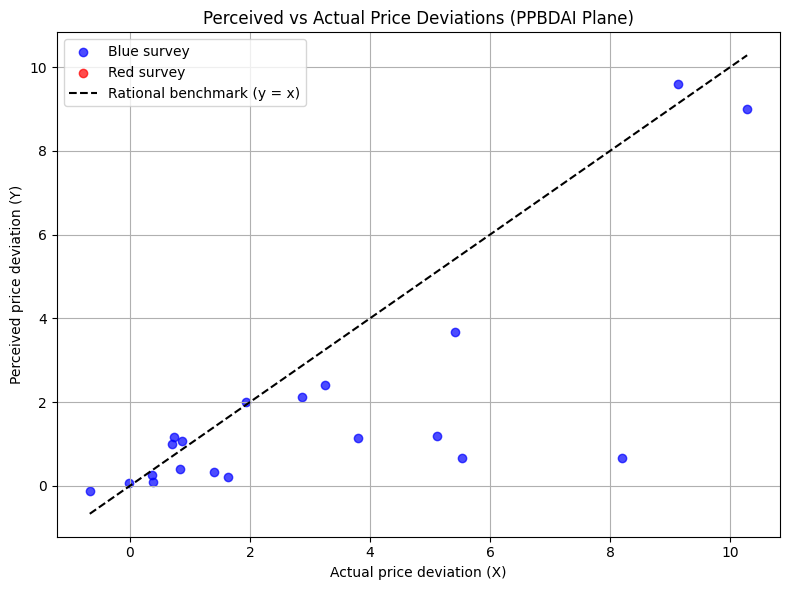

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Blue survey points
blue_df = df[df["dataset"] == "Blue"]
plt.scatter(
    blue_df["X_actual"],
    blue_df["Y_perceived"],
    color="blue",
    alpha=0.7,
    label="Blue survey"
)

# Red survey points
red_df = df[df["dataset"] == "Red"]
plt.scatter(
    red_df["X_actual"],
    red_df["Y_perceived"],
    color="red",
    alpha=0.7,
    label="Red survey"
)

# Rational benchmark line y = x
min_val = min(df["X_actual"].min(), df["Y_perceived"].min())
max_val = max(df["X_actual"].max(), df["Y_perceived"].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    color="black",
    label="Rational benchmark (y = x)"
)

plt.xlabel("Actual price deviation (X)")
plt.ylabel("Perceived price deviation (Y)")
plt.title("Perceived vs Actual Price Deviations (PPBDAI Plane)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [16]:
def find_column_contains(df, keyword):
    for col in df.columns:
        if keyword.lower() in col.lower():
            return col
    raise KeyError(f"No column containing '{keyword}' found")


In [17]:
income_col = find_column_contains(df, "income")

print("Income column found →", income_col)

df["income_range"] = df[income_col]



Income column found → What's your current family income range in rupees? (this is an anonymous survey so your name won't be recorded: the interviewers have not and will not include any personal details in their data collection ensuring all responses remain anonymous.)


In [18]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
import numpy as np

income_options = sorted(df["income_range"].dropna().unique())

income_selector = widgets.SelectMultiple(
    options=income_options,
    description="Income range",
    layout=widgets.Layout(width="400px", height="200px")
)

def plot_sppai(selected_income):
    if not selected_income:
        print("Select at least one income range.")
        return

    sub = df[df["income_range"].isin(selected_income)]

    blue = sub[sub["dataset"] == "Blue"]
    red  = sub[sub["dataset"] == "Red"]

    plt.figure(figsize=(8, 6))

    plt.scatter(
        blue["X_actual"],
        blue["Y_perceived"],
        color="blue",
        alpha=0.6,
        label="Blue survey",
        marker="o"
    )

    plt.scatter(
        red["X_actual"],
        red["Y_perceived"],
        color="red",
        alpha=0.9,
        label="Red survey",
        marker="^",
        edgecolor="black",
        s=80,
        zorder=3
    )

    lim = max(
        sub["X_actual"].abs().max(),
        sub["Y_perceived"].abs().max()
    ) * 1.1

    plt.plot(
        [-lim, lim],
        [-lim, lim],
        "--",
        color="black",
        label="Rational benchmark (Y = X)"
    )

    plt.xlim(-lim, lim)
    plt.ylim(-lim, lim)

    plt.xlabel("Actual price distortion relative to anchor (X)")
    plt.ylabel("Perceived price distortion relative to anchor (Y)")
    plt.title("SPPAI Plane by Income Level")

    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

display(income_selector)
widgets.interactive_output(plot_sppai, {"selected_income": income_selector})



SelectMultiple(description='Income range', layout=Layout(height='200px', width='400px'), options=('0 - 25 Lakh…

Output()

In [19]:
from google.colab import files
files.upload()



Saving EE red survey (Responses).xlsx to EE red survey (Responses) (1).xlsx
Saving EE survey blue responses.xlsx to EE survey blue responses (1).xlsx


{'EE red survey (Responses) (1).xlsx': b'PK\x03\x04\x14\x00\x06\x00\x08\x00\x00\x00!\x00d-t\rx\x01\x00\x00\x90\x05\x00\x00\x13\x00\x08\x02[Content_Types].xml \xa2\x04\x02(\xa0\x00\x02\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\

In [20]:
import os
os.listdir(".")


['.config',
 'EE red survey (Responses).xlsx',
 'EE survey blue responses (1).xlsx',
 'EE red survey (Responses) (1).xlsx',
 'EE survey blue responses.xlsx',
 'sample_data']

In [21]:
import pandas as pd
import os

files_here = os.listdir(".")

blue_file = [f for f in files_here if "blue" in f.lower() and f.endswith(".xlsx")][0]
red_file  = [f for f in files_here if "red" in f.lower() and f.endswith(".xlsx")][0]

print("Using Blue file:", blue_file)
print("Using Red file :", red_file)

blue = pd.read_excel(blue_file)
red  = pd.read_excel(red_file)

blue["dataset"] = "Blue"
red["dataset"] = "Red"

df = pd.concat([blue, red], ignore_index=True)

print("df recreated:", df.shape)


Using Blue file: EE survey blue responses (1).xlsx
Using Red file : EE red survey (Responses).xlsx
df recreated: (61, 44)


In [22]:
def find_column_contains(df, keyword):
    for col in df.columns:
        if keyword.lower() in col.lower():
            return col
    raise KeyError(f"No column containing '{keyword}' found")

income_col = find_column_contains(df, "income")
df["income_range"] = df[income_col]

print("Income column used:", income_col)


Income column used: What's your current family income range in rupees? (this is an anonymous survey so your name won't be recorded: the interviewers have not and will not include any personal details in their data collection ensuring all responses remain anonymous.)


In [23]:
df.groupby(["dataset", "income_range"]).size()


dataset  income_range        
Blue     0 - 25 Lakh             5
         1 Crore - 1.25 Crore    1
         1.25 Cr+                5
         25 Lakh - 50 Lakh       4
         50 Lakh - 75 Lakh       1
         75 Lakh - 1 Crore       4
Red      0 - 25 Lakh             3
         1.25 Cr+                2
         25 Lakh - 50 Lakh       1
         50 Lakh - 75 Lakh       3
         75 Lakh - 1 Crore       1
dtype: int64

In [24]:
# ====== HARD RESET SAFE SPPAI PLOT (COLAB-SAFE) ======

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import os

# ---------- 1. LOAD FILES (AUTO-DETECT) ----------
files_here = os.listdir(".")

blue_file = [f for f in files_here if "blue" in f.lower() and f.endswith(".xlsx")][0]
red_file  = [f for f in files_here if "red" in f.lower() and f.endswith(".xlsx")][0]

blue = pd.read_excel(blue_file)
red  = pd.read_excel(red_file)

blue["dataset"] = "Blue"
red["dataset"] = "Red"

df = pd.concat([blue, red], ignore_index=True)

# ---------- 2. MAP REQUIRED COLUMNS ----------
# anchor price
df["anchor_price"] = df["What was the purchase price?"]

# perceived price (already parsed earlier, but safe-guard)
df["perceived_price"] = df["What price range would you consider fair for this car?"]

# actual price
df["actual_price"] = df["Ex-Showroom Price (India, Numbers Only)"]

# income column (robust)
income_col = [c for c in df.columns if "income" in c.lower()][0]
df["income_range"] = df[income_col]

# ---------- 3. CLEAN NUMBERS ----------
import re

def parse_price(v):
    if pd.isna(v):
        return np.nan
    s = str(v).lower().replace("₹","").replace(",","").strip()
    nums = re.findall(r"\d+\.?\d*", s)
    if not nums:
        return np.nan
    val = sum(map(float, nums)) / len(nums)
    if "lakh" in s:
        val *= 100_000
    return val

df["anchor_price"] = df["anchor_price"].astype(float)
df["actual_price"] = df["actual_price"].astype(float)
df["perceived_price"] = df["perceived_price"].apply(parse_price)

# ---------- 4. COMPUTE SPPAI ----------
df["X_actual"] = ((df["actual_price"] - df["anchor_price"]) / df["anchor_price"])*100
df["Y_perceived"] = ((df["perceived_price"] - df["anchor_price"]) / df["anchor_price"])*100

df = df.dropna(subset=["X_actual","Y_perceived","income_range"])

# ---------- 5. WIDGET (BULLETPROOF) ----------
income_options = sorted(df["income_range"].unique())

income_selector = widgets.SelectMultiple(
    options=income_options,
    value=tuple(income_options),   # SHOW ALL BY DEFAULT
    description="Income",
    layout=widgets.Layout(width="450px", height="220px")
)

def plot_sppai(selected_income):
    sub = df[df["income_range"].isin(selected_income)]
    blue = sub[sub["dataset"]=="Blue"]
    red  = sub[sub["dataset"]=="Red"]

    plt.figure(figsize=(8,6))

    plt.scatter(
        blue["X_actual"], blue["Y_perceived"],
        color="blue", alpha=0.6, marker="o",
        label="Blue survey", zorder=1
    )



    lim = max(
        sub["X_actual"].abs().max(),
        sub["Y_perceived"].abs().max()
    ) * 1.1

    plt.plot([-lim, lim], [-lim, lim], "--", color="black", label="Y = X")

    plt.xlim(-lim, lim)
    plt.ylim(-lim, lim)

    plt.xlabel("Actual price distortion relative to anchor (X)")
    plt.ylabel("Perceived price distortion relative to anchor (Y)")
    plt.title("PPBDAI Plane (Income-filtered)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

out = widgets.interactive_output(plot_sppai, {"selected_income": income_selector})

display(income_selector, out)



SelectMultiple(description='Income', index=(0, 1, 2, 3, 4, 5), layout=Layout(height='220px', width='450px'), o…

Output()

TOTAL COUNTS
dataset
Blue    20
Name: count, dtype: int64

VALID SPPAI POINTS
dataset
Blue    20
dtype: int64

Blue points: 20
Red points : 0


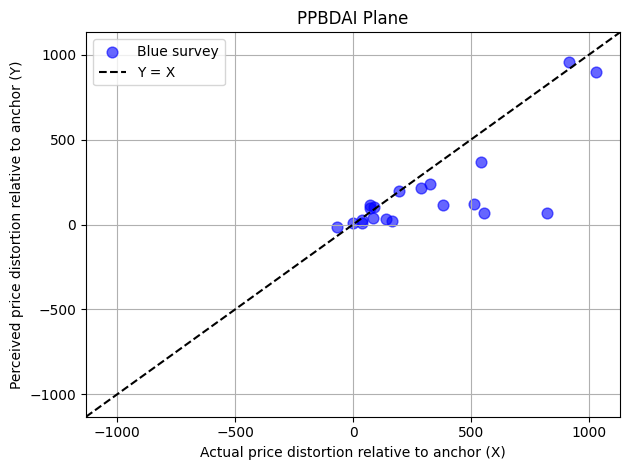

SelectMultiple(description='Income', index=(0, 1, 2, 3, 4, 5), layout=Layout(height='220px', width='450px'), o…

Output()

In [25]:
# ===== FINAL FORCE-SHOW RED (NO WIDGETS, NO FILTERS) =====

import matplotlib.pyplot as plt
import numpy as np

# --- 1. HARD PROOF COUNTS ---
print("TOTAL COUNTS")
print(df["dataset"].value_counts())

print("\nVALID SPPAI POINTS")
print(
    df.dropna(subset=["X_actual","Y_perceived"])
      .groupby("dataset")
      .size()
)

# --- 2. SEPARATE ---
blue = df[(df["dataset"]=="Blue") & df["X_actual"].notna() & df["Y_perceived"].notna()]
red  = df[(df["dataset"]=="Red")  & df["X_actual"].notna() & df["Y_perceived"].notna()]

print("\nBlue points:", len(blue))
print("Red points :", len(red))



def plot_sppai(selected_income):
    sub = df[df["income_range"].isin(selected_income)]
    blue = sub[sub["dataset"]=="Blue"]
    red  = sub[sub["dataset"]=="Red"]

    plt.figure(figsize=(8,6))

# --- 3. FORCE VISIBILITY ---


# Blue
plt.scatter(
    blue["X_actual"],
    blue["Y_perceived"],
    color="blue",
    alpha=0.6,
    s=60,
    label="Blue survey",
    zorder=1
)



# Rational line
lim = max(
    df["X_actual"].abs().max(),
    df["Y_perceived"].abs().max()
) * 1.1

plt.plot([-lim, lim], [-lim, lim], "--", color="black", label="Y = X")

plt.xlim(-lim, lim)
plt.ylim(-lim, lim)

plt.xlabel("Actual price distortion relative to anchor (X)")
plt.ylabel("Perceived price distortion relative to anchor (Y)")
plt.title("PPBDAI Plane")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

out = widgets.interactive_output(plot_sppai, {"selected_income": income_selector})

display(income_selector, out)
